STEP 0 — Configurazione
  Finestra trattamento:   24h
  Finestra vitali basali: 120min
  Finestra lab basali:    360min  |  Features target: 31

STEP 1 — Caricamento tabelle
  patient: 2,520 righe OK
  treatment: 38,290 righe OK
  apacheApsVar: 2,205 righe OK
  apachePredVar: 2,205 righe OK
  apachePatientResult: 3,676 righe OK
  admissionDx: 7,578 righe OK
  pastHistory: 12,109 righe OK
  lab: 434,660 righe OK
  vitalPeriodic: 1,634,960 righe OK
  hospital: 186 righe OK

STEP 2 — Selezione coorte
  Dataset totale            2,520
  Primo ICU stay            2,119
  Eta >= 18                 2,111
  Durata ICU >= 4h          2,019
  Y definibile              1,994

  COORTE FINALE: 1,994 pazienti

  Y=1: 162 (8.1%)

STEP 4 — Definizione A
  A=1: 394 (19.9%)  mortalita: 10.9%
  A=0: 1,586 (80.1%)  mortalita: 7.4%
  Differenza grezza: +3.5%  <- confounding by indication!

STEP 5 — Estrazione 50 covariate X
  [3] Apache score sintetici
  [13] GCS + Fisiologia Apache
  [5] Vitali basali pr

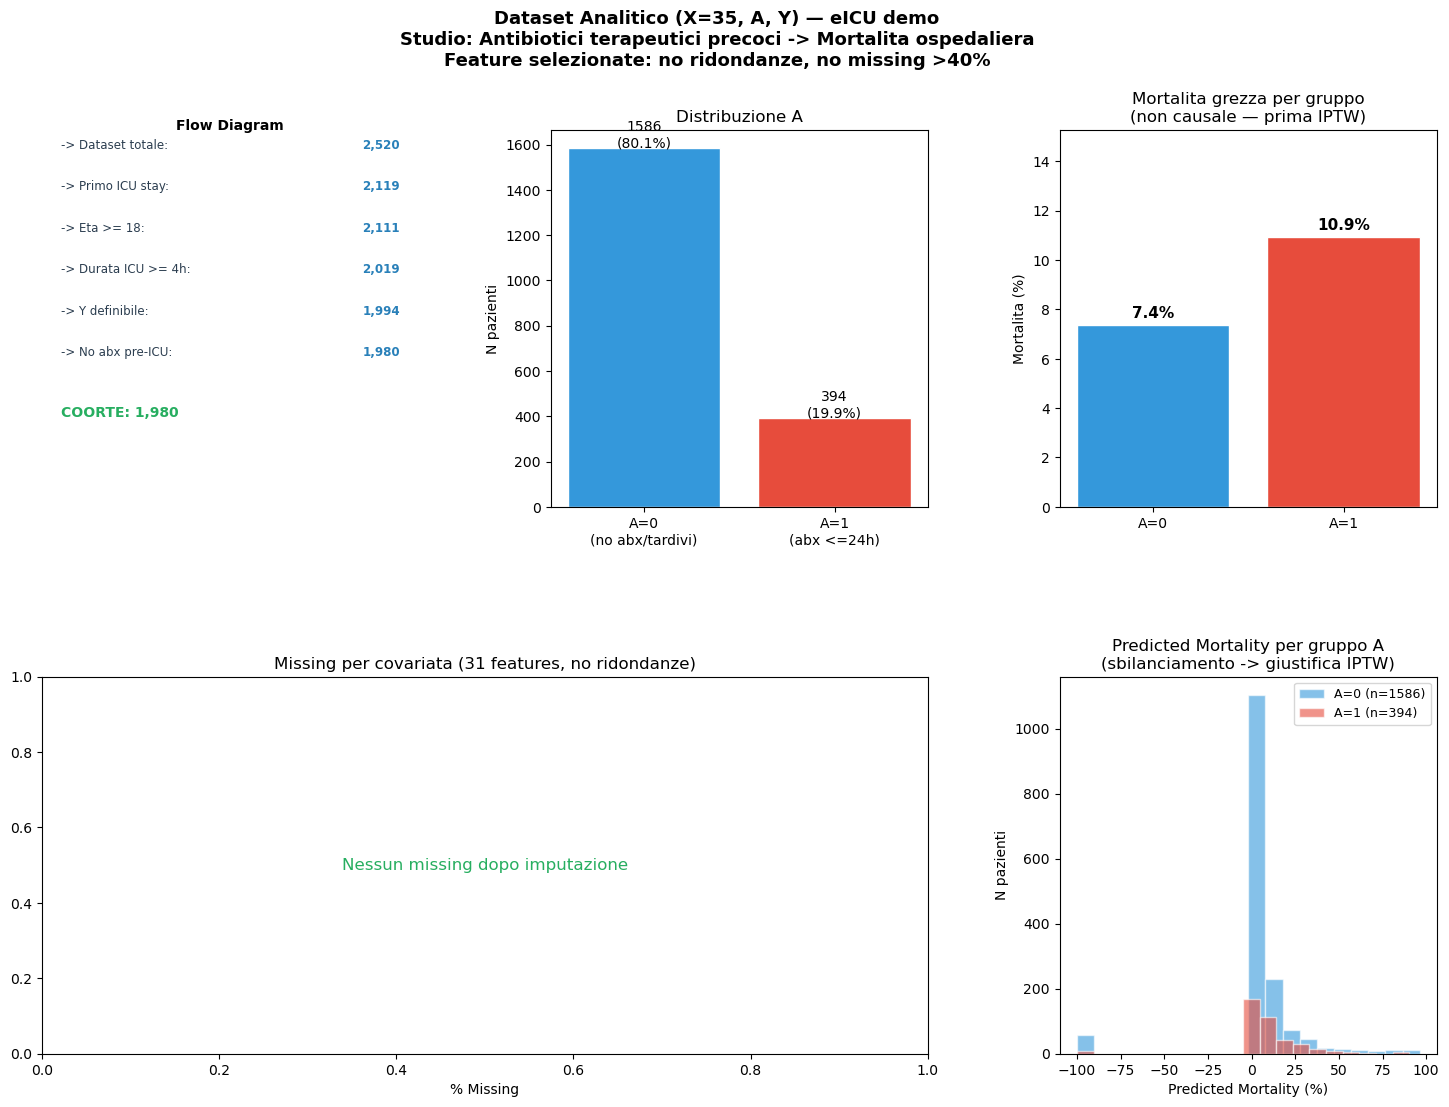

In [1]:
"""
Costruzione Dataset Analitico (X=31, A, Y) — eICU demo
Studio: Antibiotici terapeutici precoci -> Mortalita ospedaliera
Framework: Target Trial Emulation (Hernan 2022)

50 FEATURES:
  Demografiche (4):           age, gender, peso, altezza
  Apache score sintetici (3): apachescore, APS, predicted mortality
  GCS Apache (3):             eyes, motor, verbal
  Fisiologia Apache (10):     HR, MAP, RR, Temp, pH, PaO2, FiO2,
                              creatinina, WBC, glucosio
  Vitali basali 2h (5):       SpO2_min, HR, MAP, RR, Temp
  Lab basali 6h (8):          lattato, WBC, creatinina, bicarbonato,
                              glucosio, Hgb, piastrine, BUN
  Diagnosi ammissione (3):    infettiva, cardiaca, neurologica
  Comorbidita Apache (6):     diabete, cirrosi, epatopatia,
                              immunosoppressione, metastasi, AIDS
  Comorbidita storia (4):     ipertensione, scompenso, BPCO, CKD
  Clinica (1):                chirurgia elettiva
  Ospedale (3):               teaching, dimensione, regione
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

UP       = "../data/raw/"
OUT_PNG  = "../output_png/"
OUT_DATA = "../data/processed/dataset_XAY.csv"
TREAT_WIN = 24 * 60
VITAL_WIN = 120
LAB_WIN   = 360

print("=" * 60)
print("STEP 0 — Configurazione")
print(f"  Finestra trattamento:   {TREAT_WIN//60}h")
print(f"  Finestra vitali basali: {VITAL_WIN}min")
print(f"  Finestra lab basali:    {LAB_WIN}min  |  Features target: 31")

def load(name, usecols=None):
    try:
        df = pd.read_csv(f"{UP}{name}.csv", usecols=usecols)
        print(f"  {name}: {len(df):,} righe OK")
        return df
    except FileNotFoundError:
        print(f"  {name}: NON TROVATA")
        return None

print("\n" + "=" * 60)
print("STEP 1 — Caricamento tabelle")
print("=" * 60)

patient    = load("patient",    ["patientunitstayid","gender","age","hospitalid",
                                  "hospitaldischargestatus","unitdischargestatus",
                                  "unitdischargeoffset","unitvisitnumber",
                                  "admissionweight","admissionheight","hospitaladmitsource"])
treatment  = load("treatment",  ["patientunitstayid","treatmentoffset","treatmentstring"])
apache_aps = load("apacheApsVar", ["patientunitstayid","eyes","motor","verbal",
                                   "heartrate","meanbp","respiratoryrate","temperature",
                                   "ph","pao2","fio2","creatinine","wbc","glucose"])
apache_pred= load("apachePredVar",["patientunitstayid","diabetes","aids","hepaticfailure",
                                   "metastaticcancer","immunosuppression","cirrhosis","electivesurgery"])
apache_res = load("apachePatientResult",["patientunitstayid","apachescore",
                                         "acutephysiologyscore","predictedhospitalmortality"])
adm_dx     = load("admissionDx",  ["patientunitstayid","admitdxpath"])
past_hist  = load("pastHistory",  ["patientunitstayid","pasthistorypath"])
lab        = load("lab",          ["patientunitstayid","labresultoffset","labname","labresult"])
vital      = load("vitalPeriodic",["patientunitstayid","observationoffset","sao2",
                                   "heartrate","respiration","systemicmean","temperature"])
hospital   = load("hospital",     ["hospitalid","numbedscategory","teachingstatus","region"])

# STEP 2: SELEZIONE COORTE
print("\n" + "=" * 60)
print("STEP 2 — Selezione coorte")
print("=" * 60)

flow = []
N0   = len(patient)
flow.append(("Dataset totale", N0))

cohort = patient[patient["unitvisitnumber"] == 1].copy()
flow.append(("Primo ICU stay", len(cohort)))

cohort["age_num"] = cohort["age"].replace("> 89", "90")
cohort["age_num"] = pd.to_numeric(cohort["age_num"], errors="coerce")
cohort = cohort[cohort["age_num"] >= 18]
flow.append(("Eta >= 18", len(cohort)))

cohort = cohort[cohort["unitdischargeoffset"] >= 240]
flow.append(("Durata ICU >= 4h", len(cohort)))

cohort = cohort[cohort["hospitaldischargestatus"].isin(["Alive","Expired"])]
flow.append(("Y definibile", len(cohort)))

try:
    eol = pd.read_csv(f"{UP}carePlanEOL_csv.gz", usecols=["patientunitstayid"])
    n_before = len(cohort)
    cohort = cohort[~cohort["patientunitstayid"].isin(set(eol["patientunitstayid"]))]
    flow.append(("No comfort care", len(cohort)))
except:
    pass

ids = set(cohort["patientunitstayid"])
for label, n in flow:
    print(f"  {label:<25} {n:,}")
print(f"\n  COORTE FINALE: {len(cohort):,} pazienti")

# STEP 3: Y
cohort["Y"] = (cohort["hospitaldischargestatus"] == "Expired").astype(int)
print(f"\n  Y=1: {cohort['Y'].sum():,} ({cohort['Y'].mean()*100:.1f}%)")

# STEP 4: A
print("\n" + "=" * 60)
print("STEP 4 — Definizione A")
print("=" * 60)

def is_therapeutic(s):
    s = str(s).lower()
    if "prophylactic" in s: return False
    return any(k in s for k in ["therapeutic antibacterials",
        "pulmonary|medications|antibacterials",
        "cardiovascular|other therapies|antibacterials"])

tc = treatment[treatment["patientunitstayid"].isin(ids)].copy()
abx = tc[tc["treatmentstring"].apply(is_therapeutic)]
fa  = (abx.sort_values("treatmentoffset")
         .groupby("patientunitstayid").first().reset_index()
         [["patientunitstayid","treatmentoffset"]])
fa.columns = ["patientunitstayid","abx_offset"]

pre_icu = set(fa[fa["abx_offset"] < 0]["patientunitstayid"])
cohort  = cohort[~cohort["patientunitstayid"].isin(pre_icu)]
ids     = set(cohort["patientunitstayid"])
flow.append(("No abx pre-ICU", len(cohort)))

fa_valid = fa[fa["patientunitstayid"].isin(ids) & (fa["abx_offset"] >= 0)]
cohort = cohort.merge(fa_valid, on="patientunitstayid", how="left")
cohort["A"] = (cohort["abx_offset"].notna() & (cohort["abx_offset"] <= TREAT_WIN)).astype(int)

m1 = cohort[cohort["A"]==1]["Y"].mean()*100
m0 = cohort[cohort["A"]==0]["Y"].mean()*100
print(f"  A=1: {cohort['A'].sum():,} ({cohort['A'].mean()*100:.1f}%)  mortalita: {m1:.1f}%")
print(f"  A=0: {(cohort['A']==0).sum():,} ({(cohort['A']==0).mean()*100:.1f}%)  mortalita: {m0:.1f}%")
print(f"  Differenza grezza: {m1-m0:+.1f}%  <- confounding by indication!")

# STEP 5: COVARIATE X
print("\n" + "=" * 60)
print("STEP 5 — Estrazione 50 covariate X")
print("=" * 60)

df = cohort[["patientunitstayid","Y","A","age_num",
             "admissionweight","admissionheight","gender","hospitalid"]].copy()

# Apache score sintetici [3]
if apache_res is not None:
    ares = (apache_res[apache_res["patientunitstayid"].isin(ids)]
            .groupby("patientunitstayid").first().reset_index()
            [["patientunitstayid","apachescore","acutephysiologyscore","predictedhospitalmortality"]])
    df = df.merge(ares, on="patientunitstayid", how="left")
    print("  [3] Apache score sintetici")

# GCS + Fisiologia [13]
if apache_aps is not None:
    aps = (apache_aps[apache_aps["patientunitstayid"].isin(ids)]
           .groupby("patientunitstayid").first().reset_index())
    keep = ["patientunitstayid","eyes","motor","verbal",
            "heartrate","meanbp","respiratoryrate","temperature",
            "ph","pao2","fio2","creatinine","wbc","glucose"]
    aps  = aps[[c for c in keep if c in aps.columns]].copy()
    aps.columns = ["patientunitstayid"] + [f"aps_{c}" for c in aps.columns[1:]]
    df = df.merge(aps, on="patientunitstayid", how="left")
    print("  [13] GCS + Fisiologia Apache")

# Vitali basali 2h [5]
if vital is not None:
    vit = vital[vital["patientunitstayid"].isin(ids) &
                (vital["observationoffset"] >= 0) &
                (vital["observationoffset"] <= VITAL_WIN)].copy()
    vit_agg = vit.groupby("patientunitstayid").agg(
        vital_sao2_min  =("sao2",        "min"),
        vital_hr_mean   =("heartrate",   "mean"),
        vital_map_mean  =("systemicmean","mean"),
        vital_rr_mean   =("respiration", "mean"),
        vital_temp_mean =("temperature", "mean"),
    ).reset_index()
    df = df.merge(vit_agg, on="patientunitstayid", how="left")
    print("  [5] Vitali basali prime 2h")

# Lab basali 6h [8]
if lab is not None:
    lab_c = lab[lab["patientunitstayid"].isin(ids) &
                (lab["labresultoffset"] >= 0) &
                (lab["labresultoffset"] <= LAB_WIN)].copy()
    LAB_MAP = {"lactate":"lab_lactate","WBC x 1000":"lab_wbc",
               "creatinine":"lab_creatinine","bicarbonate":"lab_bicarbonate",
               "glucose":"lab_glucose","Hgb":"lab_hgb",
               "platelets x 1000":"lab_platelets","BUN":"lab_bun"}
    for lname, lcol in LAB_MAP.items():
        sub = (lab_c[lab_c["labname"]==lname].sort_values("labresultoffset")
               .groupby("patientunitstayid")["labresult"].first()
               .reset_index().rename(columns={"labresult":lcol}))
        df = df.merge(sub, on="patientunitstayid", how="left")
    print("  [8] Lab basali prime 6h")

# Diagnosi ammissione [3]
if adm_dx is not None:
    adx = adm_dx[adm_dx["patientunitstayid"].isin(ids)].copy()
    adx["infective_dx"] = adx["admitdxpath"].str.lower().str.contains(
        "sepsis|infect|pneumon|bacteremia|respiratory", na=False).astype(int)
    adx["cardiac_dx"]   = adx["admitdxpath"].str.lower().str.contains(
        "cardiovascular|cardiac|arrhythmia|heart", na=False).astype(int)
    adx["neuro_dx"]     = adx["admitdxpath"].str.lower().str.contains(
        "neurolog|coma|seizure|stroke", na=False).astype(int)
    adx_agg = adx.groupby("patientunitstayid").agg(
        infective_dx=("infective_dx","max"),
        cardiac_dx  =("cardiac_dx",  "max"),
        neuro_dx    =("neuro_dx",    "max")).reset_index()
    df = df.merge(adx_agg, on="patientunitstayid", how="left")
    print(f"  [3] Diagnosi ammissione  (infettiva: {df['infective_dx'].fillna(0).sum():.0f} pz)")

# Comorbidita Apache [6]
if apache_pred is not None:
    apred = (apache_pred[apache_pred["patientunitstayid"].isin(ids)]
             .groupby("patientunitstayid").first().reset_index()
             [["patientunitstayid","diabetes","aids","hepaticfailure",
               "metastaticcancer","immunosuppression","cirrhosis"]])
    df = df.merge(apred, on="patientunitstayid", how="left")
    print("  [6] Comorbidita Apache")

# Comorbidita storia [4]
if past_hist is not None:
    ph = past_hist[past_hist["patientunitstayid"].isin(ids)].copy()
    ph["hx_htn"]  = ph["pasthistorypath"].str.lower().str.contains("hypertension",    na=False).astype(int)
    ph["hx_chf"]  = ph["pasthistorypath"].str.lower().str.contains("heart failure|chf",na=False).astype(int)
    ph["hx_copd"] = ph["pasthistorypath"].str.lower().str.contains("copd",            na=False).astype(int)
    ph["hx_ckd"]  = ph["pasthistorypath"].str.lower().str.contains("renal|kidney",    na=False).astype(int)
    ph_agg = ph.groupby("patientunitstayid").agg(
        hx_htn=("hx_htn","max"), hx_chf=("hx_chf","max"),
        hx_copd=("hx_copd","max"), hx_ckd=("hx_ckd","max")).reset_index()
    df = df.merge(ph_agg, on="patientunitstayid", how="left")
    print("  [4] Comorbidita storia clinica")

# Chirurgia elettiva [1]
if apache_pred is not None and "electivesurgery" in apache_pred.columns:
    elec = (apache_pred[apache_pred["patientunitstayid"].isin(ids)]
            [["patientunitstayid","electivesurgery"]]
            .groupby("patientunitstayid").first().reset_index())
    df = df.merge(elec, on="patientunitstayid", how="left")
    print("  [1] Chirurgia elettiva")

# Ospedale [3] — NON la chiave, ma le caratteristiche
if hospital is not None:
    df = df.merge(hospital, on="hospitalid", how="left")
    print("  [3] Caratteristiche ospedale (teaching, size, region)")

# STEP 6: ENCODING E IMPUTAZIONE
print("\n" + "=" * 60)
print("STEP 6 — Encoding e imputazione")
print("=" * 60)

df["gender_male"] = (df["gender"] == "Male").astype(int)
df = df.drop(columns=["gender","hospitalid","teachingstatus","numbedscategory","region"], errors="ignore")

# ─────────────────────────────────────────
# ANALISI RIDONDANZE — Feature rimosse:
#
# 1. apachescore, acutephysiologyscore  (r=0.948)
#    → ridondanti con predictedhospitalmortality
#
# 2. vital_hr_mean  (r=0.737 con aps_heartrate)
#    → aps_heartrate usa valore peggiore 24h, piu informativo
#
# 3. aps_fio2  (r=0.854-0.895 con aps_ph e aps_pao2)
#    → parzialmente post-trattamento (dipende da O2 supplementare)
#    → rimane aps_pao2 (ossigenazione) + aps_ph (acido-base)
#
# GCS (aps_eyes, aps_motor, aps_verbal): r=0.80-0.89 ma TENUTI
#    → motor predice outcome diversamente da eyes/verbal
#    → correlazione alta ma non indica ridondanza clinica
# ─────────────────────────────────────────

FEATURES_31 = [
    # Demografiche (4)
    "age_num", "gender_male", "admissionweight", "admissionheight",

    # Gravita complessiva (1) — sintesi calibrata di tutta la gravita
    "predictedhospitalmortality",

    # GCS Apache (3) — stato neurologico, predittore indipendente
    "aps_eyes", "aps_motor", "aps_verbal",

    # Fisiologia Apache (8) — rimossi apachescore, acutephysiologyscore, aps_fio2
    "aps_heartrate",     # FC: marker di stress/infezione
    "aps_meanbp",        # pressione: stato emodinamico
    "aps_respiratoryrate", # FR: distress respiratorio
    "aps_temperature",   # febbre: risposta infettiva
    "aps_ph",            # acido-base: gravita metabolica
    "aps_pao2",          # ossigenazione arteriosa
    "aps_creatinine",    # funzione renale
    "aps_wbc",           # risposta infiammatoria
    "aps_glucose",       # metabolismo

    # Vitali basali 2h (1) — rimosso vital_hr_mean (ridondante con aps_heartrate)
    "vital_sao2_min",    # SpO2 minima: ipossiemia acuta

    # Diagnosi ammissione (3)
    "infective_dx",      # diagnosi infettiva/respiratoria
    "cardiac_dx",        # diagnosi cardiovascolare
    "neuro_dx",          # diagnosi neurologica

    # Comorbidita Apache (6)
    "diabetes", "cirrhosis", "hepaticfailure",
    "immunosuppression", "metastaticcancer", "aids",

    # Comorbidita storia clinica (4)
    "hx_htn", "hx_chf", "hx_copd", "hx_ckd",

    # Caratteristiche ospedale (3)
]
FEATURES_31 = [f for f in FEATURES_31 if f in df.columns]
print(f"  Feature disponibili: {len(FEATURES_31)} / 35")

# Missing report
miss_pct = df[FEATURES_31].isnull().mean()*100
print("\n  Missing per colonna (solo >0%):")
miss_report = miss_pct[miss_pct > 0].sort_values(ascending=False)
for col, pct in miss_report.items():
    flag = "ALTO >40%" if pct>40 else ("MEDIO >10%" if pct>10 else "OK")
    print(f"    {col:<35} {pct:5.1f}%  {flag}")

if len(miss_report) == 0:
    print("    Nessun missing!")

# Imputazione
BINARY = ["gender_male","hospital_teaching","hospital_midwest",
          "infective_dx","cardiac_dx","neuro_dx",
          "diabetes","cirrhosis","hepaticfailure",
          "immunosuppression","metastaticcancer","aids",
          "hx_htn","hx_chf","hx_copd","hx_ckd"]
NUM    = [f for f in FEATURES_31 if f not in BINARY + ["hospital_size"]]

df_imp = df.copy()
for col in NUM:
    if col in df_imp.columns and df_imp[col].isnull().any():
        df_imp[col] = df_imp[col].fillna(df_imp[col].median())
for col in BINARY:
    if col in df_imp.columns:
        df_imp[col] = df_imp[col].fillna(0).astype(int)

print(f"\n  Missing residui: {df_imp[FEATURES_31].isnull().sum().sum()}")


# ─────────────────────────────────────────
# 7. STEP 4.6 — SALVATAGGIO E RIEPILOGO
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 7 — Feature list e salvataggio")
print("=" * 60)

GROUPS = {
    "Demografiche (4)":          ["age_num","gender_male","admissionweight","admissionheight"],
    "Gravita globale (1)":       ["predictedhospitalmortality"],
    "GCS Apache (3)":            ["aps_eyes","aps_motor","aps_verbal"],
    "Fisiologia Apache (8)":     ["aps_heartrate","aps_meanbp","aps_respiratoryrate",
                                  "aps_temperature","aps_ph","aps_pao2",
                                  "aps_creatinine","aps_wbc","aps_glucose"],
    "Vitali basali 2h (1)":      ["vital_sao2_min"],
    "Diagnosi ammissione (3)":   ["infective_dx","cardiac_dx","neuro_dx"],
    "Comorbidita Apache (6)":    ["diabetes","cirrhosis","hepaticfailure",
                                  "immunosuppression","metastaticcancer","aids"],
    "Comorbidita storia (4)":    ["hx_htn","hx_chf","hx_copd","hx_ckd"],
}

total = 0
for group, cols in GROUPS.items():
    avail = [c for c in cols if c in df_imp.columns]
    total += len(avail)
    print(f"  {group:<28} {len(avail):>2} features")
print(f"\n  TOTALE: {total} features")

final_cols = ["patientunitstayid","Y","A"] + FEATURES_31
df_final   = df_imp[[c for c in final_cols if c in df_imp.columns]].copy()
df_final.to_csv(OUT_DATA, index=False)
print(f"\n  Salvato: {OUT_DATA}  |  Shape: {df_final.shape}")

desc = df_final.groupby("A").agg(
    N=("Y","count"),
    mortalita_pct=("Y","mean"),
    age_media=("age_num","mean"),
    predicted_mort_media=("predictedhospitalmortality","mean"),
).round(3)
desc["mortalita_pct"] = (desc["mortalita_pct"]*100).round(1)
desc["predicted_mort_media"] = (desc["predicted_mort_media"]*100).round(1)
print("\n  Descrittive per gruppo A:")
print(desc.to_string())


# ─────────────────────────────────────────
# 8. FIGURA
# ─────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Dataset Analitico (X=35, A, Y) — eICU demo\n"
             "Studio: Antibiotici terapeutici precoci -> Mortalita ospedaliera\n"
             "Feature selezionate: no ridondanze, no missing >40%",
             fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Flow diagram
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis("off")
y_pos = 0.95
ax1.text(0.5, 1.0, "Flow Diagram", ha="center",
         fontweight="bold", transform=ax1.transAxes)
for label, n in flow:
    ax1.text(0.05, y_pos, f"-> {label}:", transform=ax1.transAxes,
             fontsize=8.5, color="#2c3e50")
    ax1.text(0.95, y_pos, f"{n:,}", transform=ax1.transAxes,
             fontsize=8.5, ha="right", color="#2980b9", fontweight="bold")
    y_pos -= 0.11
ax1.text(0.05, y_pos-0.05, f"COORTE: {len(df_final):,}",
         transform=ax1.transAxes, fontsize=10,
         color="#27ae60", fontweight="bold")

# Distribuzione A
ax2 = fig.add_subplot(gs[0, 1])
counts = df_final["A"].value_counts().sort_index()
bars = ax2.bar(["A=0\n(no abx/tardivi)","A=1\n(abx <=24h)"],
               counts.values, color=["#3498db","#e74c3c"], edgecolor="white")
ax2.set_title("Distribuzione A")
ax2.set_ylabel("N pazienti")
for bar, v in zip(bars, counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
             f"{v}\n({v/len(df_final)*100:.1f}%)", ha="center", fontsize=10)

# Mortalita grezza
ax3 = fig.add_subplot(gs[0, 2])
mort = df_final.groupby("A")["Y"].mean()*100
ax3.bar(["A=0","A=1"], mort.values, color=["#3498db","#e74c3c"], edgecolor="white")
ax3.set_title("Mortalita grezza per gruppo\n(non causale — prima IPTW)")
ax3.set_ylabel("Mortalita (%)")
ax3.set_ylim(0, mort.max()*1.4)
for i, v in enumerate(mort.values):
    ax3.text(i, v+0.3, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")

# Missing per feature
ax4 = fig.add_subplot(gs[1, 0:2])
miss_feat = df_final[FEATURES_31].isnull().mean()*100
miss_feat = miss_feat[miss_feat > 0].sort_values()
if len(miss_feat) > 0:
    ax4.barh(miss_feat.index, miss_feat.values,
             color=["#f39c12" if v>10 else "#2ecc71" for v in miss_feat.values])
    ax4.axvline(10, color="orange", ls="--", alpha=0.7, label="10%")
    ax4.legend(fontsize=8)
else:
    ax4.text(0.5, 0.5, "Nessun missing dopo imputazione",
             ha="center", va="center", transform=ax4.transAxes,
             fontsize=12, color="#27ae60")
ax4.set_title("Missing per covariata (31 features, no ridondanze)")
ax4.set_xlabel("% Missing")

# Predicted mortality per gruppo A
ax5 = fig.add_subplot(gs[1, 2])
if "predictedhospitalmortality" in df_final.columns:
    for a_val, color, label in [(0,"#3498db","A=0"),(1,"#e74c3c","A=1")]:
        data = df_final[df_final["A"]==a_val]["predictedhospitalmortality"].dropna()*100
        ax5.hist(data, bins=20, alpha=0.6, color=color,
                 label=f"{label} (n={len(data)})", edgecolor="white")
    ax5.set_title("Predicted Mortality per gruppo A\n(sbilanciamento -> giustifica IPTW)")
    ax5.set_xlabel("Predicted Mortality (%)")
    ax5.set_ylabel("N pazienti")
    ax5.legend(fontsize=9)

plt.savefig(f"{OUT_PNG}dataset_XAY_summary.png", dpi=150, bbox_inches="tight")
print(f"\n  Figura salvata: dataset_XAY_summary.png")
print("\nScript completato — 31 features, no ridondanze, no missing >40%")